In [1]:
import sys
sys.path.append(r'C:\Users\sadiq\Desktop\U_Vienna\codes\icm-zebrafish')
sys.path.append(r'C:/Users/sadiq/Desktop/U_Vienna/codes/icm-zebrafish/Mathilde/new_data_09112022/220119_F2_run11')
%matplotlib inline
import numpy as np
from new_utils import *
from d_CSL import *
import pickle
import matplotlib.pyplot as plt
from scipy.signal import resample
from mpl_toolkits.mplot3d import axes3d
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from d_CSL import *

In [3]:
N_PASTS, n_lags, n_perm = list(range(2)), 1, 1000
alpha, beta = 0.001, 0.001

In [4]:
%%time

# load data
os.chdir(r'./data/pairs/')
names = ['pair0001.txt', 'pair0003.txt', 'pair0004.txt','pair0005.txt', 'pair0012.txt', 'pair0013.txt', 'pair0014.txt', 
         'pair0015.txt', 'pair0016.txt', 'pair0017.txt', 'pair0038.txt', 'pair0043.txt', 'pair0044.txt', 'pair0063.txt', 
         'pair0094.txt', 'pair0100.txt']
INFs = {}
for i in range(len(names)):
    data = np.loadtxt(names[i])
    X = data.T
    print(names[i])
    print('')
    
    # Analysis
    infs = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        corr, pVal = correlation_func(X, n_perm, n)
        inf = np.multiply(corr, pVal<=alpha)
        np.fill_diagonal(inf, 0)
        infs.append(inf)
    print('')
    print('')
    INFs[i] = infs

pair0001.txt

0 pasts


C:\Users\sadiq\Desktop\U_Vienna\codes\icm-zebrafish\d_CSL.py:106: NumbaExperimentalFeatureWarning: Use of isinstance() detected. This is an experimental feature.
  count, corr_1 = 0,np.corrcoef(x,y)[1,0]


1 pasts


pair0003.txt

0 pasts
1 pasts


pair0004.txt

0 pasts
1 pasts


pair0005.txt

0 pasts
1 pasts


pair0012.txt

0 pasts
1 pasts


pair0013.txt

0 pasts
1 pasts


pair0014.txt

0 pasts
1 pasts


pair0015.txt

0 pasts
1 pasts


pair0016.txt

0 pasts
1 pasts


pair0017.txt

0 pasts
1 pasts


pair0038.txt

0 pasts
1 pasts


pair0043.txt

0 pasts
1 pasts


pair0044.txt

0 pasts
1 pasts


pair0063.txt

0 pasts
1 pasts


pair0094.txt

0 pasts
1 pasts


pair0100.txt

0 pasts
1 pasts


CPU times: total: 34.2 s
Wall time: 26.3 s


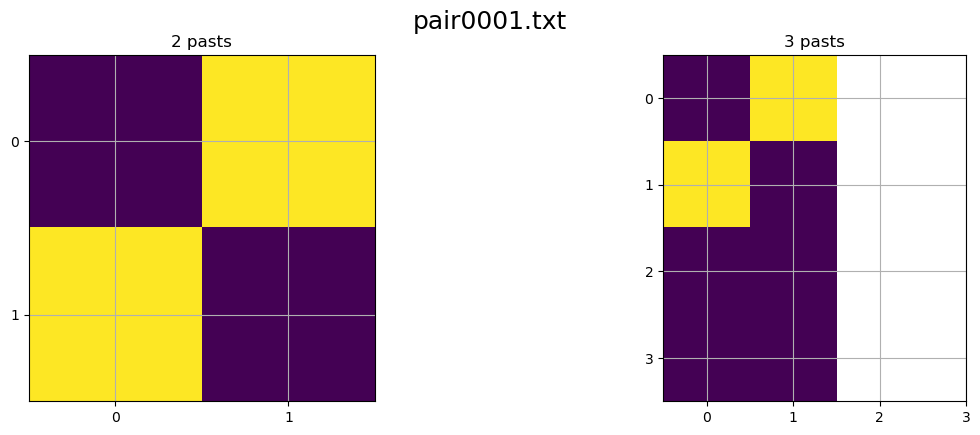

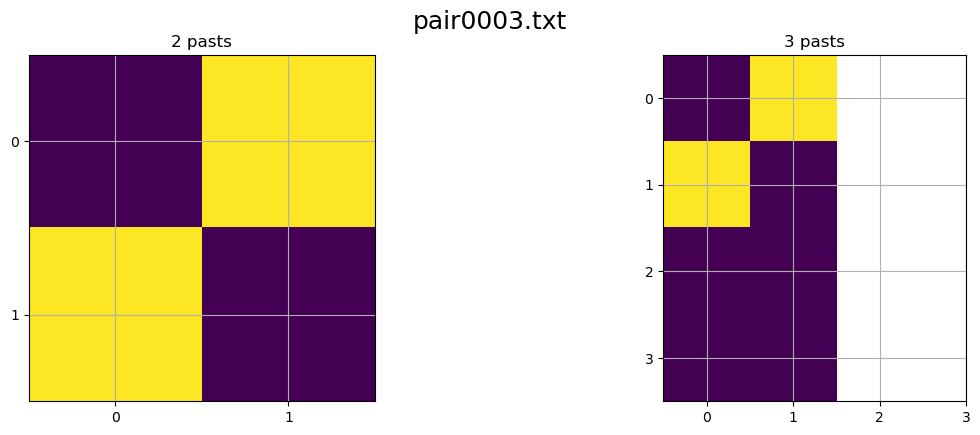

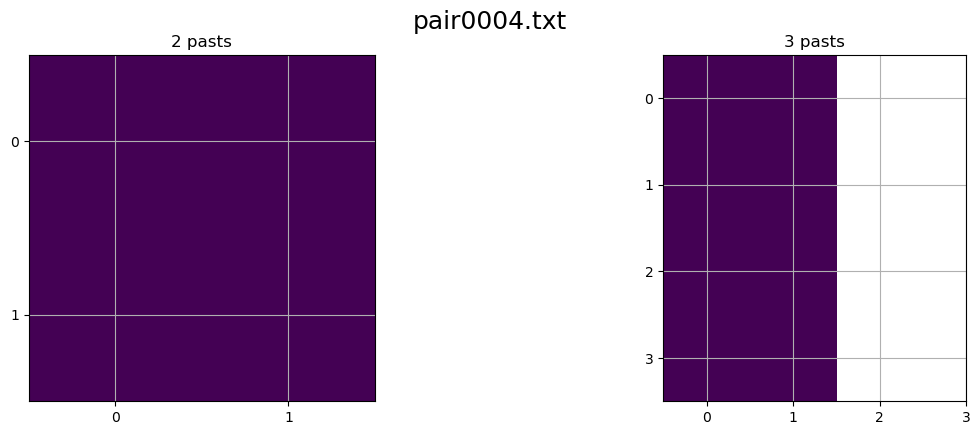

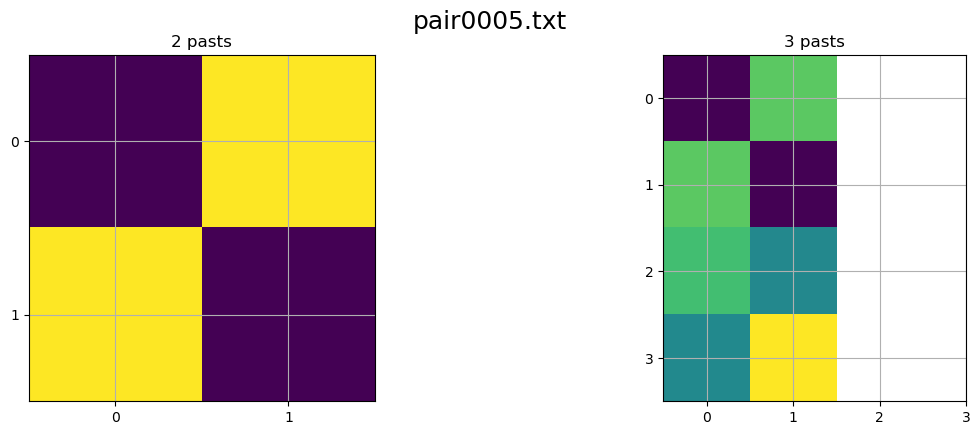

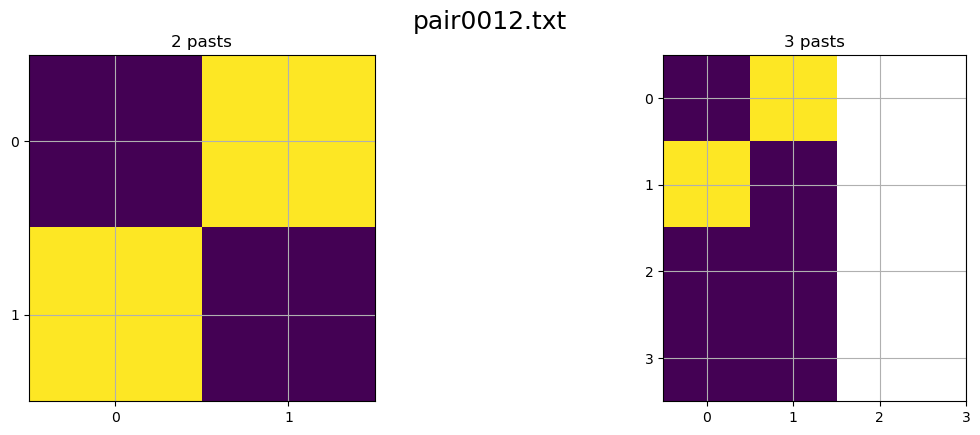

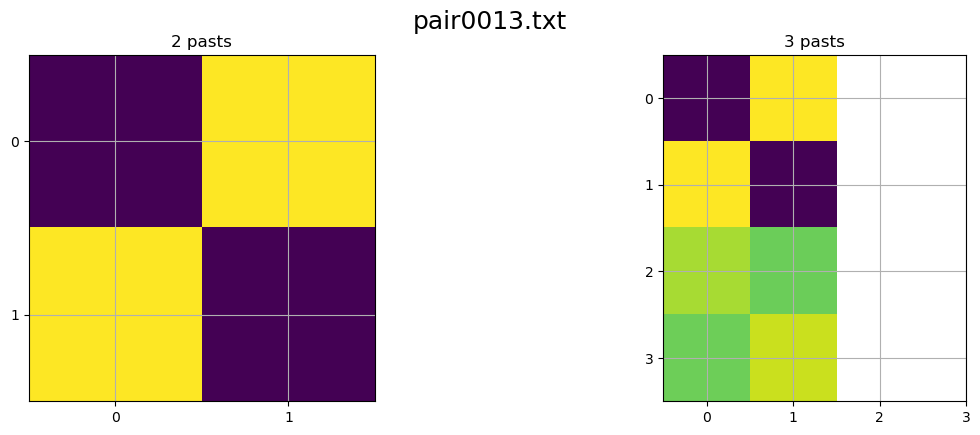

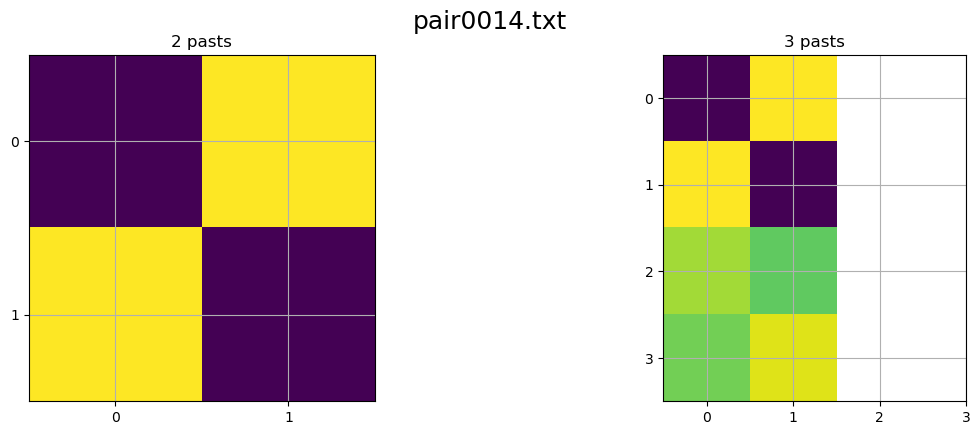

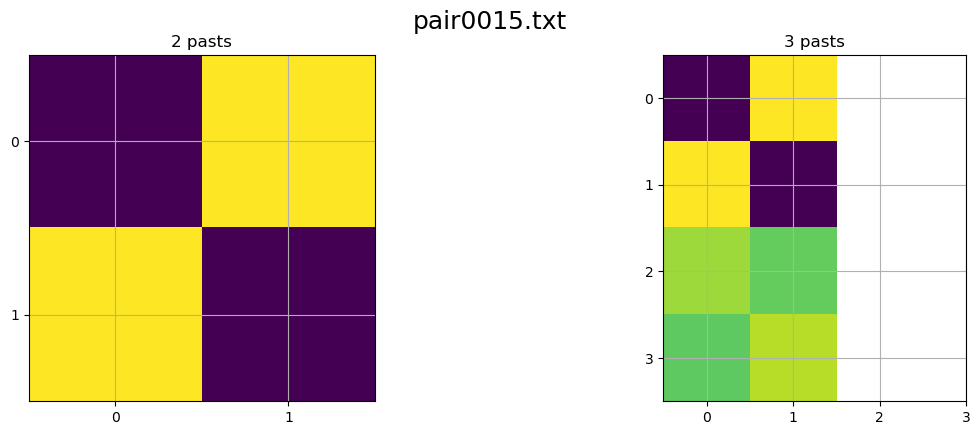

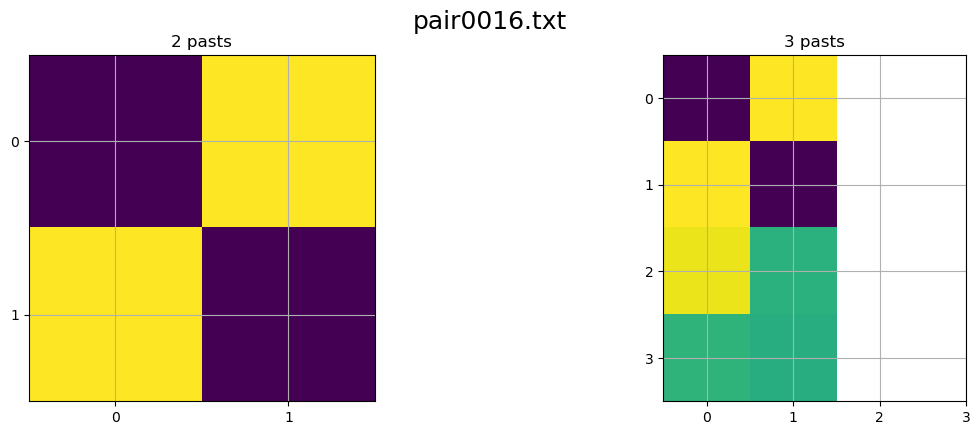

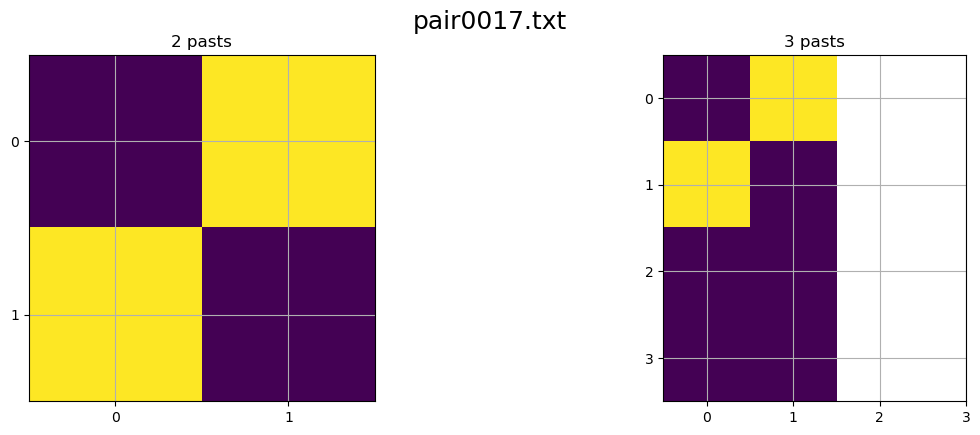

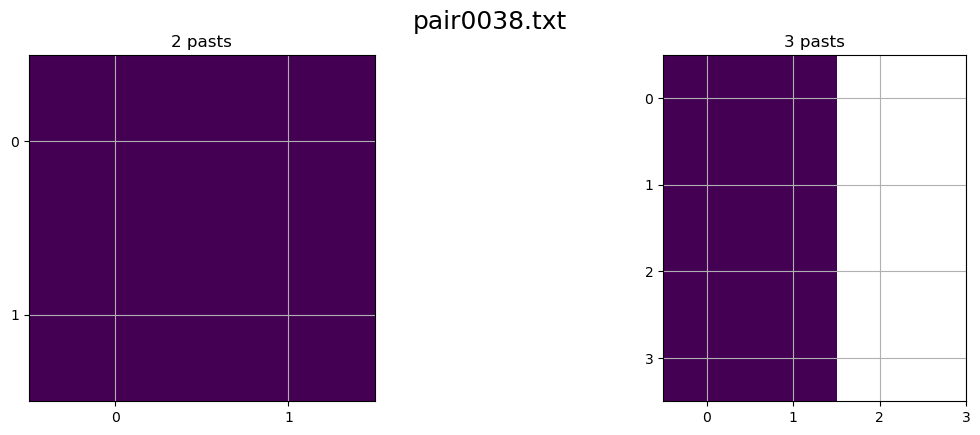

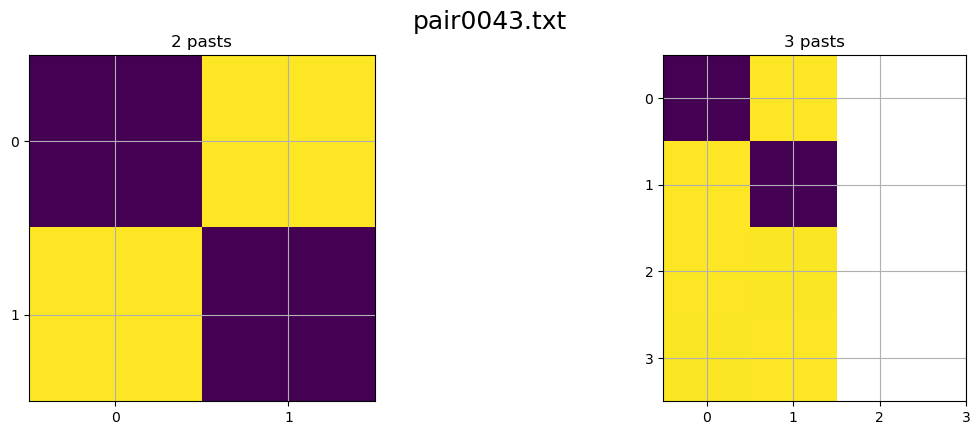

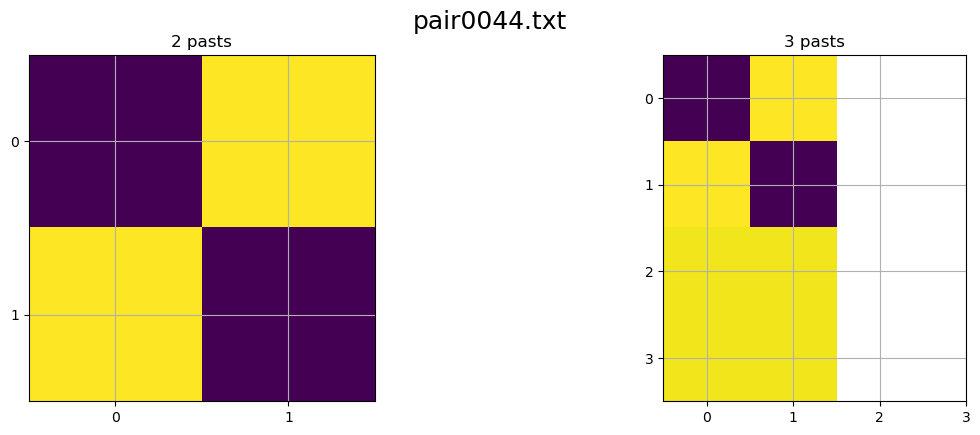

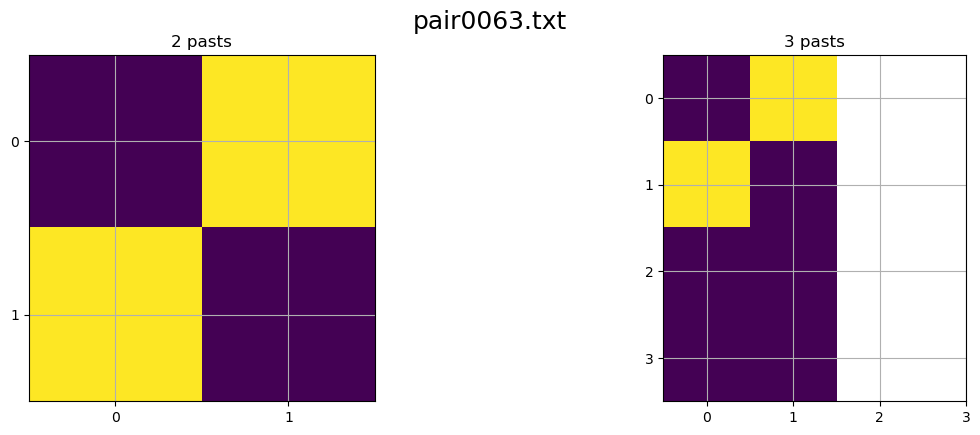

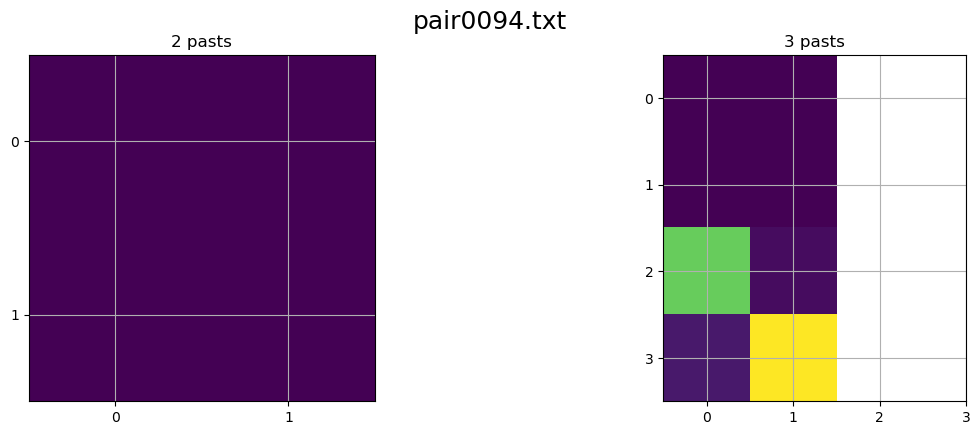

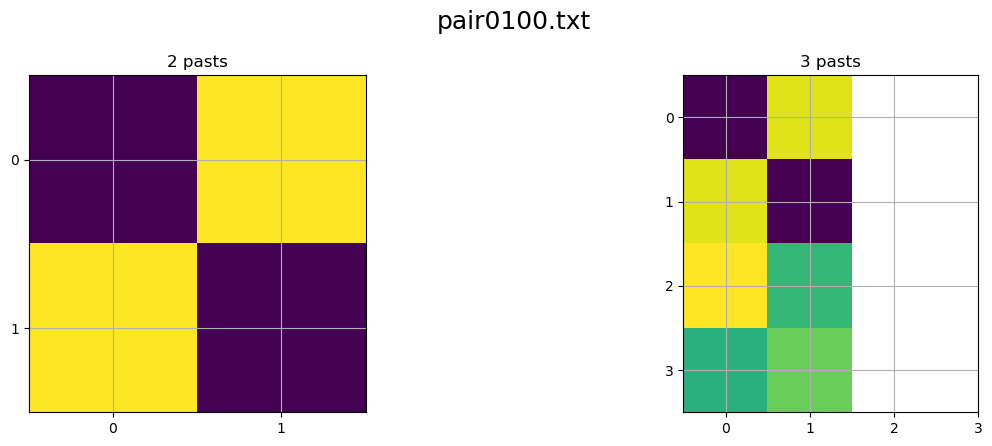

In [6]:
for i in range(len(names)):
  fig,ax = plt.subplots(1,2,figsize=(14.5,4.5))
  for j in range(2):
    ax[j].imshow(INFs[i][j])
    ax[j].set_title(f'{j+2} pasts')
    ax[j].set_xticks(np.arange(INFs[i][j].shape[0]))
    ax[j].set_yticks(np.arange(INFs[i][j].shape[0]))
    ax[j].grid()
  plt.suptitle(f'{names[i]}', fontsize=18)
plt.tight_layout()